# Partie 1 — Chargement et exploration
## 1.1 Chargement et constitution du corpus de titres


* Les imports

In [4]:
import re
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

import spacy

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    auc,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Embedding, LSTM, Bidirectional, TextVectorization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

nltk.download("punkt", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

In [5]:
nlp = spacy.load("en_core_web_sm")
print("Modèle spaCy chargé.")

Modèle spaCy chargé.


**Écrivez une fonction load_titles(filepath: str) -> pd.DataFrame qui :**

* Charge le fichier CSV
* Sélectionne et renomme les colonnes utiles : title → text, label → label
* Convertit les labels textuels en entiers : REAL → 1, FAKE → 0
* Supprime les lignes dont le titre est vide ou nul
* Affiche un résumé : nombre de titres par classe, proportion, longueur moyenne
* Sauvegardez le DataFrame résultant dans data/titles_clean.csv.

In [6]:


def load_titles(filepath: str) -> pd.DataFrame:

    # Chargement du fichier
    df = pd.read_csv(filepath)

    # Sélection des colonnes title et label
    df = df[["title", "label"]].copy()

    # Renommage de la colonne title en text (label est déja bien nommée)
    df = df.rename(columns={"title": "text"})

    # Remplace des Nan par une chaine vide
    df["text"] = df["text"].fillna("").astype(str).str.strip()
    
    # Récuperation uniquement des colonnes text non vide
    df = df[df["text"] != ""].copy()

    # Convertit les labels textuels en entiers : REAL → 1, FAKE → 0 
    df["label"] = df["label"].map({"REAL": 1, "FAKE": 0})

    # Création d'une colonne nb_tokens qui contient le nombre de mots du texte
    df["nb_tokens"] = df["text"].apply(lambda x: len(str(x).split()))

    # Affichage de la distribution de la classe label 
    print("Nombre de titres par classe :")
    print(df["label"].value_counts())

    # Affcihage des proportions
    print("\nProportions :")
    vcn = df["label"].value_counts(normalize=True)
    
    pct_real = round(vcn.loc[1], 4) * 100
    pct_fake = round(vcn.loc[0], 4) * 100

    print(f"Pourcentage de news REAL : {pct_real}%")
    print(f"Pourcentage de news FAKE : {pct_fake}%")

    print("\nLongueur moyenne des titres :", int(df["nb_tokens"].mean()), "mots")

    df.to_csv("../data/titles_clean.csv", index=False)

    return df

df = load_titles("../data/news.csv")
print(df.head())

Nombre de titres par classe :
label
1    3171
0    3164
Name: count, dtype: int64

Proportions :
Pourcentage de news REAL : 50.06%
Pourcentage de news FAKE : 49.94%

Longueur moyenne des titres : 10 mots
                                                text  label  nb_tokens
0                       You Can Smell Hillary’s Fear      0          5
1  Watch The Exact Moment Paul Ryan Committed Pol...      0         14
2        Kerry to go to Paris in gesture of sympathy      1          9
3  Bernie supporters on Twitter erupt in anger ag...      0         15
4   The Battle of New York: Why This Primary Matters      1          9


## 1.2 Analyse exploratoire

* Distribution des classes : le corpus est-il équilibré ? Si non, quelle stratégie envisagez-vous ?

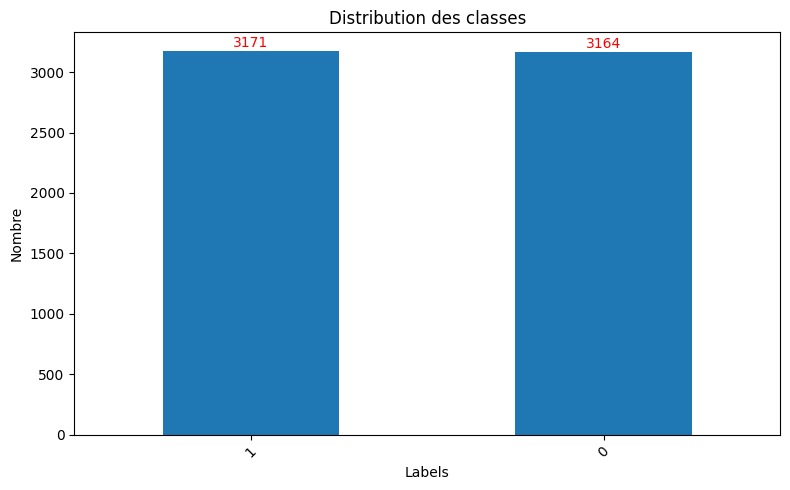

In [7]:
counts = df["label"].value_counts()

plt.figure(figsize=(8, 5))
ax = counts.plot(kind="bar")
ax.set_xlabel("Labels")
ax.tick_params(axis='x', rotation=45)
ax.set_ylabel("Nombre")
ax.set_title("Distribution des classes")
ax.bar_label(ax.containers[0], padding=1,color="red")
plt.tight_layout()
plt.show()

**=> On peut considérer que le corpus est équilibré avec 50.06% de REAL et 49.94% de FAKE**  

* Distribution de la longueur des titres en tokens : histogramme par classe, valeurs min / max / médiane

REAL
----------
Le nombre minimum de mots par titre : 2
Le nombre maximum de mots par titre : 27
La médiane de mots par titre : 10
FAKE
----------
Le nombre minimum des mots par titre : 1
Le nombre maximum des mots par titre : 53
La médiane des mots par titre : 11


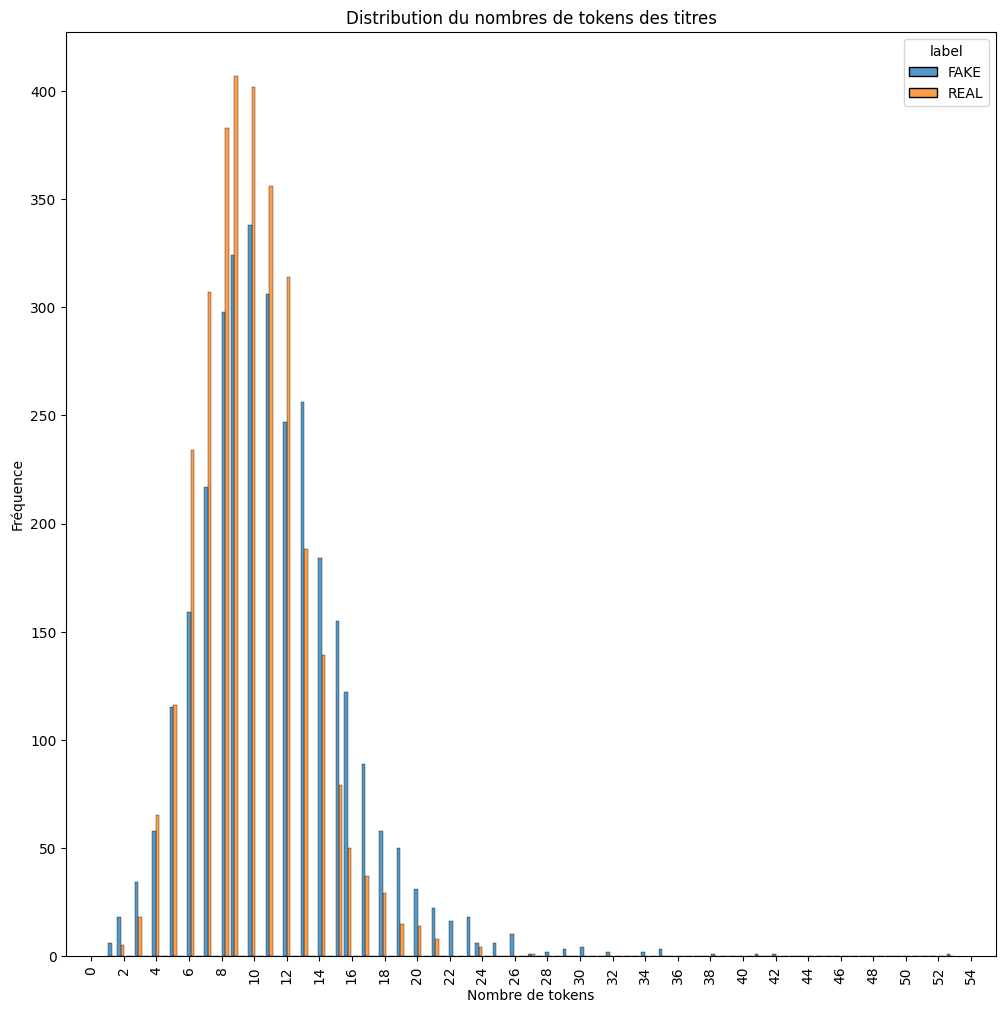

In [ ]:
real_nb_tokens = df[df["label"] == 1]["nb_tokens"]
fake_nb_tokens = df[df["label"] == 0]["nb_tokens"]

# Affichage pour les titres REAL
print("REAL")
print("-"*10)
print(f"Le nombre minimum de mots par titre : {real_nb_tokens.min()}")
print(f"Le nombre maximum de mots par titre : {real_nb_tokens.max()}")
print(f"La médiane de mots par titre : {int(real_nb_tokens.median())}")

print("=" * 30) # Ligne de séparation

# Affichage pour les titres FAKE
print("FAKE")
print("-"*10)
print(f"Le nombre minimum des mots par titre : {fake_nb_tokens.min()}")
print(f"Le nombre maximum des mots par titre : {fake_nb_tokens.max()}")
print(f"La médiane des mots par titre : {int(fake_nb_tokens.median())}")


import seaborn as sns
legend_map = {1: "REAL", 0: "FAKE"}
plt.figure(figsize=(12, 12))
sns.histplot(data=df, x='nb_tokens', hue=df['label'].map(legend_map), multiple="dodge", shrink=0.8)
# On garde tes graduations précises
plt.xticks(np.arange(0, 56, 2), rotation=90)
plt.title("Distribution du nombres de tokens des titres")
plt.xlabel("Nombre de tokens")
plt.ylabel("Fréquence")

plt.show()

**=> On observe qu'au delà de 27 tokens dans le titres, il y a une forte probabilité d'être sur une FAKE news. Par contre, on**
**observe également que les titres FAKE et REAL sont concentrés entre 4 et 16 tokens en majorité. La longueur ne suffit pas**
**pour déterminer si on a affaire à un titre FAKE ou REAL**

* Top 20 des tokens les plus fréquents dans chaque classe — affichez deux diagrammes en barres côte à côte

Top 20 REAL :
[('to', 724), ('the', 635), ('in', 500), ('Trump', 432), ('of', 392), ('for', 332), ('The', 319), ('a', 299), ('on', 293), ('Clinton', 285), ('and', 282), ('is', 254), ('GOP', 213), ('Obama', 193), ('Donald', 185), ('Hillary', 168), ('Why', 136), ('How', 118), ('2016', 114), ('House', 109)]

Top 20 FAKE :
[('The', 580), ('to', 559), ('the', 532), ('of', 472), ('in', 353), ('Trump', 348), ('To', 314), ('Hillary', 304), ('on', 296), ('and', 279), ('for', 262), ('Clinton', 250), ('a', 194), ('Is', 186), ('In', 185), ('by', 172), ('–', 171), ('-', 161), ('A', 159), ('Of', 152)]


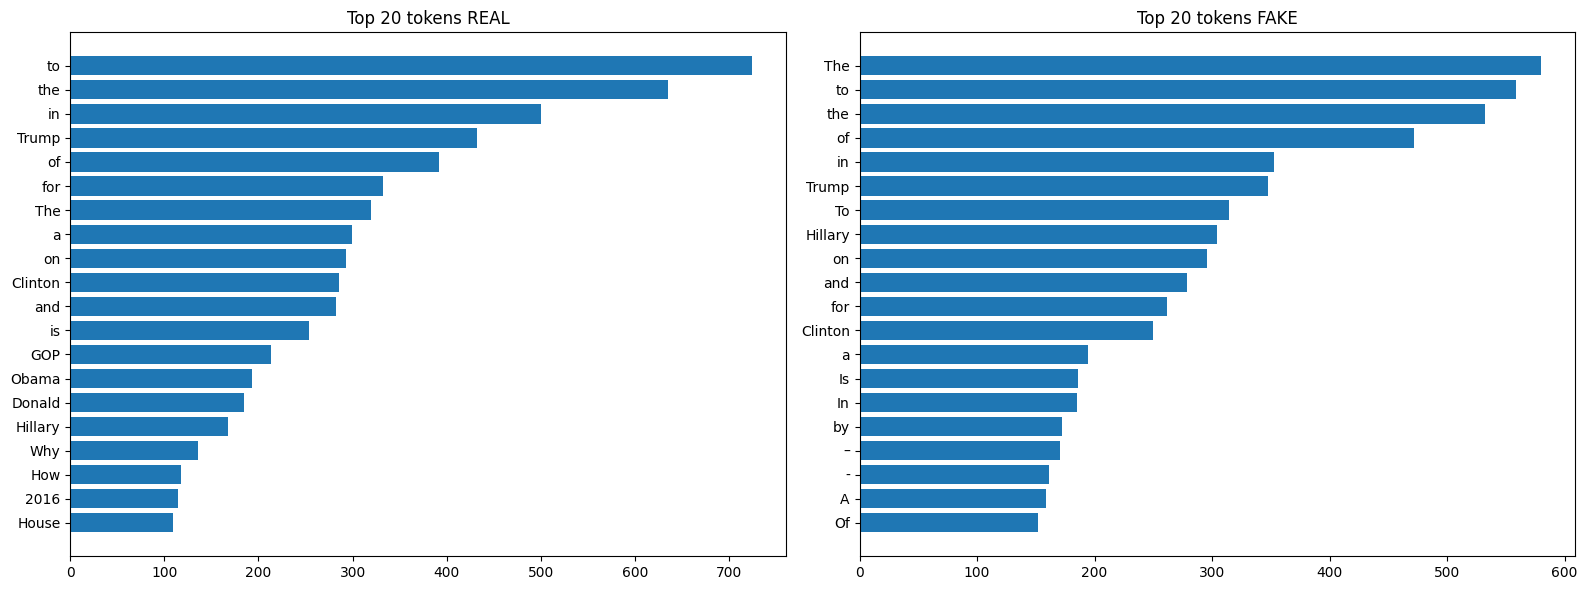

In [9]:
df["tokens"] = df["text"].str.split()

def get_list_tokens(dataframe):
    list_tokens = []
    for list_words in dataframe["tokens"]:
        for word in list_words:
            list_tokens.append(word)
    return list_tokens

df_real = df[df["label"] == 1].copy()
df_fake = df[df["label"] == 0].copy()

list_tokens_real = get_list_tokens(df_real)
list_tokens_fake = get_list_tokens(df_fake)

list_occ_tokens_real = Counter(list_tokens_real)
list_occ_tokens_fake = Counter(list_tokens_fake)

print("Top 20 REAL :")
print(list_occ_tokens_real.most_common(20))

print("\nTop 20 FAKE :")
print(list_occ_tokens_fake.most_common(20))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

words_real, counts_real = zip(*list_occ_tokens_real.most_common(20))
axes[0].barh(words_real, counts_real)
axes[0].set_title("Top 20 tokens REAL")
axes[0].invert_yaxis()

words_fake, counts_fake = zip(*list_occ_tokens_fake.most_common(20))
axes[1].barh(words_fake, counts_fake)
axes[1].set_title("Top 20 tokens FAKE")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()



* Identification des tokens présents dans une seule classe (discriminants purs) : listez les 10 premiers par classe

10 tokens discriminants REAL :
[('GOP', 199), ('to', 165), ('in', 147), ('Obama', 145), ('Donald', 106), ('a', 105), ('is', 105), ('the', 103), ('Sanders', 92), ('debate', 91)]

10 tokens discriminants FAKE :
[('The', 261), ('To', 226), ('–', 154), ('-', 141), ('Hillary', 136), ('by', 122), ('Comment', 104), ('Election', 101), ('Is', 99), ('Of', 97)]


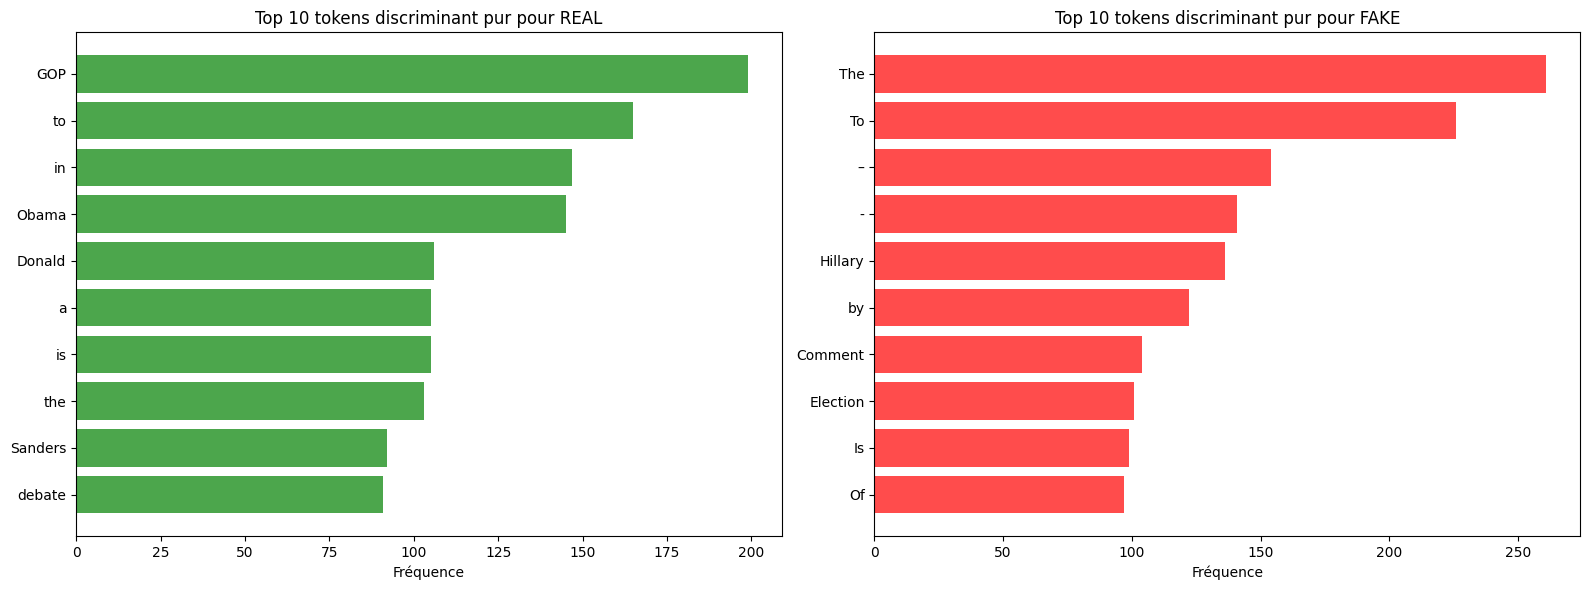

In [10]:
list_discr_pur_real = list_occ_tokens_real - list_occ_tokens_fake
list_discr_pur_fake = list_occ_tokens_fake - list_occ_tokens_real

print("10 tokens discriminants REAL :")
print(list_discr_pur_real.most_common(10))

print("\n10 tokens discriminants FAKE :")
print(list_discr_pur_fake.most_common(10))

list_discr_pur_real = list_occ_tokens_real - list_occ_tokens_fake
list_discr_pur_fake = list_occ_tokens_fake - list_occ_tokens_real

# # Visualisation
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 20 tokens real
words_pos, counts_pos = zip(*list_discr_pur_real.most_common(10))
axes[0].barh(words_pos, counts_pos, color='green', alpha=0.7)
axes[0].set_xlabel('Fréquence')
axes[0].set_title('Top 10 tokens discriminant pur pour REAL')
axes[0].invert_yaxis()

# 20 tokens fake
words_neg, counts_neg = zip(*list_discr_pur_fake.most_common(10))
axes[1].barh(words_neg, counts_neg, color='red', alpha=0.7)
axes[1].set_xlabel('Fréquence')
axes[1].set_title('Top 10 tokens discriminant pur pour FAKE')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

**=> On observe que malgré la volonté de ne garder que les discriminat pur pour chaque label, la casse des caractères laisse passer des tokens**
**identiques comme par exemple "The" et "the", "is" et Is" etc...** 

 **Identifiez au moins 3 titres potentiellement ambigus (ni clairement fiables, ni clairement trompeurs) et expliquez pourquoi ils posent problème**

1. "Kerry to go to Paris in gesture of sympathy" (REAL) :
        titre très neutre et informatif, sans marqueur émotionnel ou sensationnaliste. Il pourrait facilement être inventé car il manque de contexte, ce qui le rend difficile à classer.

2. "Bernie supporters on Twitter erupt in anger against the DNC: 'We tried to warn you!'" (REAL) :
       la présence de termes émotionnels comme "erupt" et "anger" peut faire penser à une fake news ou à un contenu biaisé, alors qu’il s’agit d’une réaction réelle. La frontière entre information et opinion est floue.

3. "Bernie Sanders Says He Will Not Be a Candidate in 2020" (FAKE) :
       le titre est formulé de manière factuelle et neutre, sans éléments sensationnalistes. Il peut facilement être perçu comme une information réelle, ce qui le rend ambigu.

**=> Ces titres posent problème car ils montrent que la détection de fake news ne dépend pas seulement de mots**
**sensationnalistes. Certains titres faux ressemblent à de vraies dépêches, tandis que certains titres réels emploient**
**un vocabulaire émotionnel ou polémique. La frontière entre REAL et FAKE n’est donc pas toujours visible uniquement dans**
**la forme du titre.**

# Partie 2 — Nettoyage et prétraitement
## 2.1 Pipeline de nettoyage

In [ ]:
# implémentez un dictionnaire d'au moins 20 contractions courantes
contractions_dict = {
    "isn't": "is not",
    "aren't": "are not",
    "can't": "cannot",
    "can't've": "cannot have",
    "couldn't": "could not",
    "didn't": "did not",
    "doesn't": "does not",
    "don't": "do not",
    "hadn't": "had not",
    "hasn't": "has not",
    "haven't": "have not",
    "he'd": "he would",
    "he'll": "he will",
    "he's": "he is",
    "i'm": "i am",
    "i've": "i have",
    "it's": "it is",
    "let's": "let us",
    "shouldn't": "should not",
    "won't": "will not",
    "wouldn't": "would not"
}

def clean_title(text: str) -> str:
    # Mise en minuscules
    text = text.lower()

    # Suppression des URLs et des mentions de type @username
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = re.sub(r"@\w+", "", text)

    text = re.sub(r"[^a-z0-9\s']", " ", text)
    
    # Suppression de la ponctuation et des chiffres isolés
    text = re.sub(r"\b\d+\b", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    temp_text = []
    split_text = text.split()
    for word in split_text :
        if word in contractions_dict :
            temp_text.append(contractions_dict[word])
        else :
            temp_text.append(word)
    
    text = " ".join(temp_text)

    # Supprimer les stopwords sauf "not", "no", "never", "neither"
    stop_words = set(stopwords.words('english'))
    words_filtered = []
    for word in text.split() :
        if word in ["not", "no", "never", "neither"] or word not in stop_words :
            words_filtered.append(word)

    # Lemmatisation avec spaCy (modèle en_core_web_sm)
    doc = nlp(" ".join(words_filtered))
    lemmas = [token.lemma_ for token in doc if len(token.lemma_) >= 2]

    return " ".join(lemmas)

print(clean_title("I'd like to don't work because i bought a new z skateboard"))

like not work buy new skateboard


 
La conservation des mots de négation est essentielle car supprimer des termes comme *not*, *no* ou *never* peut inverser complètement le sens d’un titre. Dans un contexte de détection de désinformation, cela peut conduire le modèle à apprendre une version erronée de l’information.

Exemples tirés du corpus :
1. **"Bernie Sanders Says He Will Not Be a Candidate in 2020"** : si l’on supprime *not*, le titre devient l’inverse de l’information initiale.
2. **"Donald Trump Is Changing His Campaign Slogan to Prove He’s Not Racist"** : supprimer *not* transformerait le sens du titre en affirmant qu’il est raciste, ce qui modifie totalement l’interprétation.

In [12]:
df["text_clean"] = df["text"].apply(clean_title)
df = df[df["text_clean"].str.strip() != ""].copy()
print(df[["text","text_clean"]].head(5))

                                                text  \
0                       You Can Smell Hillary’s Fear   
1  Watch The Exact Moment Paul Ryan Committed Pol...   
2        Kerry to go to Paris in gesture of sympathy   
3  Bernie supporters on Twitter erupt in anger ag...   
4   The Battle of New York: Why This Primary Matters   

                                          text_clean  
0                                 smell hillary fear  
1  watch exact moment paul ryan commit political ...  
2                    kerry go paris gesture sympathy  
3  bernie supporter twitter erupt anger dnc we tr...  
4                     battle new york primary matter  


## 2.2 Mesure de l'impact du nettoyage




Question écrite : Pourquoi la conservation des mots de négation est-elle particulièrement importante dans un contexte de détection de désinformation ? Donnez deux exemples concrets tirés du corpus.

* La taille du vocabulaire avant et après nettoyage

In [13]:
vocab_before = set(" ".join(df["text"].str.lower()).split())
vocab_after = set(" ".join(df["text_clean"]).split())

nb_vocab_before = len(vocab_before)
nb_vocab_after = len(vocab_after)
print("Taille vocabulaire avant nettoyage :", nb_vocab_before )
print("Taille vocabulaire après nettoyage :", nb_vocab_after)
print()
print(f"Après nettoyage, le vocabulaire a diminué de {round((1- nb_vocab_after/nb_vocab_before)*100,2)}%")

Taille vocabulaire avant nettoyage : 14449
Taille vocabulaire après nettoyage : 7848

Après nettoyage, le vocabulaire a diminué de 45.68%


* Le nombre de titres devenus vides après nettoyage : comment les gérez-vous ?

In [14]:
df["tokens_clean"] = df["text_clean"].str.split()
df["nb_tokens_clean"] = df["tokens_clean"].str.len()

print(df[df["nb_tokens_clean"]==0])

print("Nombre de titres vides après nettoyage :", (df["nb_tokens_clean"] == 0).sum())

df = df[df["nb_tokens_clean"] != 0].copy()

Empty DataFrame
Columns: [text, label, nb_tokens, tokens, text_clean, tokens_clean, nb_tokens_clean]
Index: []
Nombre de titres vides après nettoyage : 0


**=> On décidera de retirer les titres ayant une liste de tokens vide pour éviter des traitements inutiles et les erreurs** 


* La réduction moyenne de la longueur des titres (en tokens)

In [15]:

print(df[["tokens","nb_tokens","tokens_clean","nb_tokens_clean"]].head(5))
avg_reduction_length = (df["nb_tokens"] - df["nb_tokens_clean"]).mean()
print()
print("=> Réduction moyenne de la longueur des titres :", int(avg_reduction_length))



                                              tokens  nb_tokens  \
0                 [You, Can, Smell, Hillary’s, Fear]          5   
1  [Watch, The, Exact, Moment, Paul, Ryan, Commit...         14   
2  [Kerry, to, go, to, Paris, in, gesture, of, sy...          9   
3  [Bernie, supporters, on, Twitter, erupt, in, a...         15   
4  [The, Battle, of, New, York:, Why, This, Prima...          9   

                                        tokens_clean  nb_tokens_clean  
0                             [smell, hillary, fear]                3  
1  [watch, exact, moment, paul, ryan, commit, pol...               11  
2              [kerry, go, paris, gesture, sympathy]                5  
3  [bernie, supporter, twitter, erupt, anger, dnc...                9  
4               [battle, new, york, primary, matter]                5  

=> Réduction moyenne de la longueur des titres : 3


# Partie 3 — Représentation vectorielle
## 3.1 Vectorisation TF-IDF


**Transformez les titres nettoyés en vecteurs numériques avec TfidfVectorizer de scikit-learn.**

* Paramètres à utiliser :

TfidfVectorizer(
    max_features=3000,
    min_df=2,
    max_df=0.85,
    ngram_range=(1, 2),
    sublinear_tf=True
)
* Découpez le corpus en train (80 %) et test (20 %) avec stratification sur les labels et random_state=42
* Entraînez le vectoriseur uniquement sur le train, transformez train et test séparément
* Sauvegardez le vectoriseur avec joblib

In [16]:
X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    df["text_clean"],
    df["label"],
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df["label"]
)

tfidf = TfidfVectorizer(
    max_features=3000,
    min_df=2,
    max_df=0.85,
    ngram_range=(1, 2),
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train_clean).toarray()
X_test_tfidf = tfidf.transform(X_test_clean).toarray()

print("Shape train TF-IDF :", X_train_tfidf.shape)
print("Shape test TF-IDF :", X_test_tfidf.shape)

joblib.dump(tfidf, "../models/vectorizer.pkl")

Shape train TF-IDF : (5066, 3000)
Shape test TF-IDF : (1267, 3000)


['../models/vectorizer.pkl']

## 3.2 Embedding avec TensorFlow
**En parallèle du TF-IDF, préparez une seconde représentation basée sur des embeddings appris :**

* Utilisez tf.keras.layers.TextVectorization pour construire un vocabulaire d'index à partir des titres bruts (non lemmatisés)
* Fixez max_tokens=5000 et output_sequence_length=30 (padding/truncation)
* Cette couche sera intégrée directement dans les modèles de la Partie 4
* Question écrite : Quelle différence fondamentale y a-t-il entre un vecteur TF-IDF et un vecteur d'embedding appris ? Laquelle de ces deux représentations est capable de capturer que misleading et deceptive sont sémantiquement proches ? Justifiez.

In [17]:
# --------------------------------------------------------

# creation d'une colonne text_raw_emb suite à des problèmes avec certains caractères dans le texte (caractères cyrilliques par exemple)

import unicodedata 

df["text_raw_emb"] = (
    df["text"]
    .fillna("")
    .astype(str)
    .str.strip()
    .str.lower()
)

def normalize(text: str) -> str:
    return unicodedata.normalize("NFKD", text).encode("ascii", "ignore").decode("utf-8")

df["text_raw_emb"] = df["text_raw_emb"].apply(normalize)
#------------------------------------------------------------

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    df["text_raw_emb"],
    df["label"],
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df["label"]
)

text_vectorizer = TextVectorization(
    max_tokens=5000,
    output_sequence_length=30,
    standardize="lower_and_strip_punctuation"
)

text_vectorizer.adapt(X_train_raw.to_numpy())

print("Taille vocabulaire TextVectorization :", len(text_vectorizer.get_vocabulary()))


Taille vocabulaire TextVectorization : 5000


**Le TF-IDF traite les mots comme des termes indépendants. Il représente un texte à partir de la fréquence et de l’importance des mots**
**dans le corpus, mais il ne comprend pas leur sens. Pour lui, “misleading” et “deceptive” sont simplement deux mots différents.**
**L’embedding, au contraire, représente chaque mot sous forme de vecteur dense dans un espace mathématique. Les mots utilisés dans des contextes**
**proches ont tendance à être placés près les uns des autres. Ainsi, “misleading” et “deceptive” peuvent avoir des représentations proches car ils apparaissent**
**souvent dans des contextes similaires.**




# Partie 4 — Modélisation
## 4.1 Modèle baseline — réseau dense sur TF-IDF
**Construisez un premier modèle avec l'API Sequential de TensorFlow, prenant en entrée les vecteurs TF-IDF :**

**Architecture minimale :**

* Dense(256, activation='relu')
* Dropout(0.4)
* Dense(128, activation='relu')
* Dropout(0.3)
* Dense(1, activation='sigmoid')
* Compilez avec optimizer='adam', loss='binary_crossentropy', metrics=['accuracy']
* Entraînez sur 30 epochs avec validation_split=0.15

**Utilisez les callbacks suivants :**
* EarlyStopping(patience=5, restore_best_weights=True, monitor='val_loss')
* ModelCheckpoint pour sauvegarder le meilleur modèle

**Tracez les courbes de loss et d'accuracy (train vs validation)**

In [18]:
import time 

early_stop_dense = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

checkpoint_dense = ModelCheckpoint(
    "../models/best_model.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

model_dense = Sequential([
    Dense(256, activation="relu", input_shape=(X_train_tfidf.shape[1],)),
    Dropout(0.4),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

model_dense.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

start_dense = time.time()

history_dense = model_dense.fit(
    X_train_tfidf,
    y_train_clean,
    validation_split=0.15,
    epochs=30,
    callbacks=[early_stop_dense, checkpoint_dense],
    verbose=1
)
dense_train_time = time.time() - start_dense
print(f"Temps d'entraînement Dense : {dense_train_time:.2f} s")

Epoch 1/30


c:\farid\ECF4-ikhadriouene-farid\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


127/135 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5843 - loss: 0.6698
Epoch 1: val_loss improved from None to 0.44845, saving model to ../models/best_model.keras

Epoch 1: finished saving model to ../models/best_model.keras
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6900 - loss: 0.5975 - val_accuracy: 0.7895 - val_loss: 0.4484
Epoch 2/30
114/135 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8407 - loss: 0.3699
Epoch 2: val_loss did not improve from 0.44845
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8662 - loss: 0.3139 - val_accuracy: 0.7934 - val_loss: 0.5044
Epoch 3/30
115/135 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9134 - loss: 0.2133
Epoch 3: val_loss did not improve from 0.44845
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9271 - loss: 0.1849 - val_accuracy: 0.7882 - val_loss: 0.5775
Epoch 4/30
115/135 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9574 - loss: 0.1222
Epoch 4: val_loss did not improve from 0.44845
135/135 ━━━━━━━━━━━━━

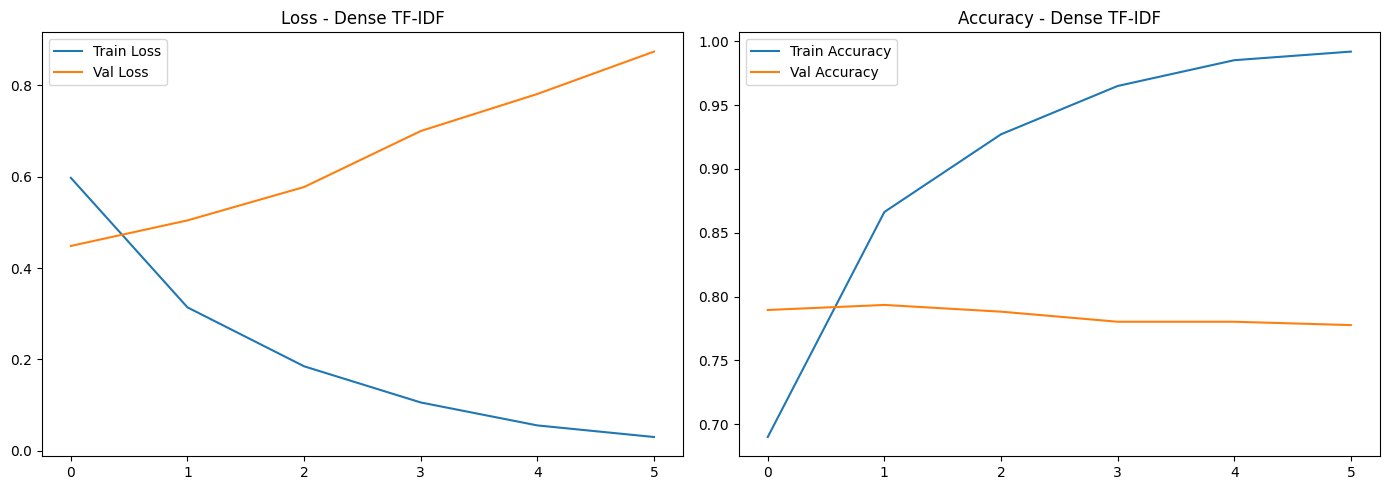

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_dense.history["loss"], label="Train Loss")
axes[0].plot(history_dense.history["val_loss"], label="Val Loss")
axes[0].set_title("Loss - Dense TF-IDF")
axes[0].legend()

axes[1].plot(history_dense.history["accuracy"], label="Train Accuracy")
axes[1].plot(history_dense.history["val_accuracy"], label="Val Accuracy")
axes[1].set_title("Accuracy - Dense TF-IDF")
axes[1].legend()

plt.tight_layout()
plt.show()

**=> On observe un fort surapprentissage. La courbe Train Loss tend vers 0 (99% d'accuracy) alors que la courbe Val Loss est à la hausse**
**ce qui est un signe que le modèle mémorise au lieu de généraliser.**

In [20]:
# Analyse de l'overfitting
train_loss_final = history_dense.history['loss'][-1]
val_loss_final = history_dense.history['val_loss'][-1]
overfitting_gap = val_loss_final - train_loss_final

print(f"Train Loss Final: {train_loss_final:.4f}")
print(f"Val Loss Final: {val_loss_final:.4f}")
print(f"Overfitting Gap: {overfitting_gap:.4f}")

if overfitting_gap < 0.05:
    print("Peu d'overfitting détecté")
elif overfitting_gap < 0.15:
    print("Overfitting modéré")
else:
    print("=> Overfitting significatif")

Train Loss Final: 0.0301
Val Loss Final: 0.8739
Overfitting Gap: 0.8438
=> Overfitting significatif


# 4.2 Modèle avec embeddings appris — architecture séquentielle
**Construisez un second modèle intégrant la couche TextVectorization et une couche Embedding :**

**Architecture :**

* TextVectorization (vocab_size=5000, sequence_length=30)
* Embedding(input_dim=5000, output_dim=64, mask_zero=True)
* Bidirectional(LSTM(64, dropout=0.2, recurrent_dropout=0.2))
* Dense(64, activation='relu')
* Dropout(0.3)
* Dense(1, activation='sigmoid')
* Même configuration de compilation et de callbacks que le modèle 4.1
* Entraînez sur 30 epochs
* Tracez les courbes d'apprentissage

In [21]:
early_stop_bilstm = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

checkpoint_bilstm = ModelCheckpoint(
    "../models/best_model_bilstm.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

callbacks=[early_stop_bilstm, checkpoint_bilstm]

model_bilstm = Sequential([
    keras.Input(shape=(1,), dtype=tf.string),
    text_vectorizer,
    Embedding(input_dim=5000, output_dim=64, mask_zero=True),
    Bidirectional(LSTM(64, dropout=0.2, recurrent_dropout=0.2)),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

model_bilstm.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Conversion explicite en tenseurs TensorFlow (conforme au moteur Keras/Optree)
X_train_raw_tensor = tf.convert_to_tensor(X_train_raw.values, dtype=tf.string)
y_train_raw_tensor = tf.convert_to_tensor(y_train_raw.values, dtype=tf.int32)

start_bilstm = time.time()

# Lancement de l'entraînement avec les tenseurs
history_bilstm = model_bilstm.fit(
    X_train_raw_tensor,
    y_train_raw_tensor,
    validation_split=0.15,
    epochs=30,
    callbacks=callbacks,
    verbose=1
)

bilstm_train_time = time.time() - start_bilstm
print(f"Temps d'entraînement BiLSTM : {bilstm_train_time:.2f} s")

Epoch 1/30
133/135 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6012 - loss: 0.6454
Epoch 1: val_loss improved from None to 0.47150, saving model to ../models/best_model_bilstm.keras

Epoch 1: finished saving model to ../models/best_model_bilstm.keras
135/135 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.6986 - loss: 0.5687 - val_accuracy: 0.7895 - val_loss: 0.4715
Epoch 2/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8599 - loss: 0.3367
Epoch 2: val_loss did not improve from 0.47150
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.8874 - loss: 0.2823 - val_accuracy: 0.8066 - val_loss: 0.4839
Epoch 3/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9310 - loss: 0.1891
Epoch 3: val_loss did not improve from 0.47150
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9422 - loss: 0.1591 - val_accuracy: 0.8013 - val_loss: 0.5506
Epoch 4/30
134/135 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9589 - loss: 0.1250
Epoch 4: val_loss did not improve fr

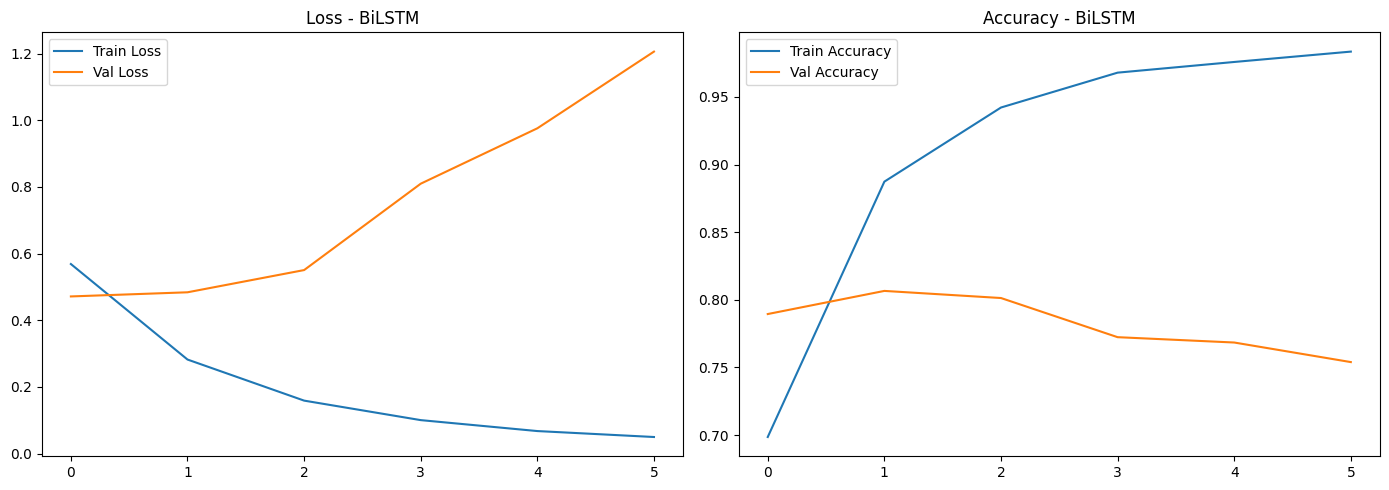

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_bilstm.history["loss"], label="Train Loss")
axes[0].plot(history_bilstm.history["val_loss"], label="Val Loss")
axes[0].set_title("Loss - BiLSTM")
axes[0].legend()

axes[1].plot(history_bilstm.history["accuracy"], label="Train Accuracy")
axes[1].plot(history_bilstm.history["val_accuracy"], label="Val Accuracy")
axes[1].set_title("Accuracy - BiLSTM")
axes[1].legend()

plt.tight_layout()
plt.show()

**=> on observe qu'il y a de l'overfitting**

In [23]:
# Analyse de l'overfitting
train_loss_final = history_bilstm.history['loss'][-1]
val_loss_final = history_bilstm.history['val_loss'][-1]
overfitting_gap = val_loss_final - train_loss_final

print(f"Train Loss Final: {train_loss_final:.4f}")
print(f"Val Loss Final: {val_loss_final:.4f}")
print(f"Overfitting Gap: {overfitting_gap:.4f}")

if overfitting_gap < 0.05:
    print("=> Peu d'overfitting détecté")
elif overfitting_gap < 0.15:
    print("=> Overfitting modéré")
else:
    print("=> Overfitting significatif")

Train Loss Final: 0.0499
Val Loss Final: 1.2057
Overfitting Gap: 1.1558
=> Overfitting significatif


# 4.3 Comparaison des deux architectures
**Remplissez le tableau suivant avec vos résultats mesurés sur l'ensemble de test :**

* Critère	Modèle Dense (TF-IDF)	Modèle LSTM Bidirectionnel
* Accuracy (test)		
* Precision — classe FAKE		
* Recall — classe FAKE		
* F1-score (macro)		
* AUC-ROC		
* Epochs effectifs (EarlyStopping)		
* Nombre de paramètres entraînables		
* Temps d'entraînement (approx.)		
* Question écrite : Lequel des deux modèles recommanderiez-vous pour une mise en production ? Justifiez votre choix en tenant compte à la fois des performances et des contraintes opérationnelles (temps de réponse, maintenance, volume de données).

In [24]:
y_proba_dense = model_dense.predict(X_test_tfidf, verbose=0).ravel()
y_pred_dense = (y_proba_dense >= 0.5).astype(int)

X_test_raw_array = X_test_raw.to_numpy(dtype=str)


# Conversion en tenseur string pour Keras
X_test_raw_tensor = tf.convert_to_tensor(X_test_raw.values, dtype=tf.string)

# Prédiction avec le tenseur
y_proba_bilstm = model_bilstm.predict(X_test_raw_tensor, verbose=0).ravel()
y_pred_bilstm = (y_proba_bilstm >= 0.5).astype(int)

dense_params = model_dense.count_params()
bilstm_params = model_bilstm.count_params()


comparison_models_df = pd.DataFrame({
    "modele": [
        "modele Dense (TF-IDF)",
        "modele LSTM Bidirectionnel"
    ],
    "accuracy": [
        accuracy_score(y_test_clean, y_pred_dense),
        accuracy_score(y_test_raw, y_pred_bilstm)
    ],
    "precision": [
        precision_score(y_test_clean, y_pred_dense, pos_label=0),
        precision_score(y_test_raw, y_pred_bilstm, pos_label=0)
    ],
    "recall": [
        recall_score(y_test_clean, y_pred_dense, pos_label=0),
        recall_score(y_test_raw, y_pred_bilstm, pos_label=0)
    ],
    "f1-score": [
        f1_score(y_test_clean, y_pred_dense, average="macro"),
        f1_score(y_test_raw, y_pred_bilstm, average="macro")
    ],
    "AUC-ROC": [
        roc_auc_score(y_test_clean, y_proba_dense),
        roc_auc_score(y_test_raw, y_proba_bilstm)
    ],
    "epochs effectifs": [
        len(history_dense.history["loss"]),
        len(history_bilstm.history["loss"])
    ],
    "nombre de paramètres entraînables": [
        dense_params,
        bilstm_params
    ],
    "temps d'entraînement (approx.)": [
        f"{dense_train_time:.2f} s",
        f"{bilstm_train_time:.2f} s"
    ]
})

print(comparison_models_df)

def get_best_model(df):
    scores = {modele: 0 for modele in df["modele"]}

    higher_is_better = ["accuracy", "precision", "recall", "f1-score", "AUC-ROC"]
    lower_is_better = ["epochs effectifs", "nombre de paramètres entraînables", "temps d'entraînement (approx.)"]

    for metric in higher_is_better:
        best_value = df[metric].max()
        winners = df[df[metric] == best_value]["modele"].tolist()
        for winner in winners:
            scores[winner] += 1

    for metric in lower_is_better:
        values = df[metric]

        if metric == "temps d'entraînement (approx.)":
            values = values.str.replace(" s", "", regex=False).astype(float)

        best_value = values.min()
        winners = df[values == best_value]["modele"].tolist()
        for winner in winners:
            scores[winner] += 1

    best_model = max(scores, key=scores.get)

    print("Scores :", scores)
    print("Meilleur modèle :", best_model)

    return best_model

best_model = get_best_model(comparison_models_df)



                       modele  accuracy  precision    recall  f1-score  \
0       modele Dense (TF-IDF)  0.805841   0.789238  0.834123  0.805692   
1  modele LSTM Bidirectionnel  0.767167   0.703614  0.922591  0.761458   

    AUC-ROC  epochs effectifs  nombre de paramètres entraînables  \
0  0.882011                 6                             801281   
1  0.880355                 6                             394369   

  temps d'entraînement (approx.)  
0                         3.07 s  
1                        17.69 s  
Scores : {'modele Dense (TF-IDF)': 6, 'modele LSTM Bidirectionnel': 3}
Meilleur modèle : modele Dense (TF-IDF)


**=> Le Modèle LSTM Bidirectionnel est techniquement plus puissant et pourrait surpasser le modèle Dense avec un**
**volume de données **beaucoup plus important. Cependant, sur le volume de données actuel, le Modèle Dense offre le meilleur compromis : il est plus performant, plus rapide**

# Partie 5 — Évaluation approfondie
## 5.1 Analyse des performances du meilleur modèle
**Sur l'ensemble de test, calculez et affichez pour votre meilleur modèle :**

* La matrice de confusion annotée (valeurs absolues + pourcentages)
* Le rapport de classification complet (precision, recall, F1 par classe)
* La courbe ROC avec l'AUC

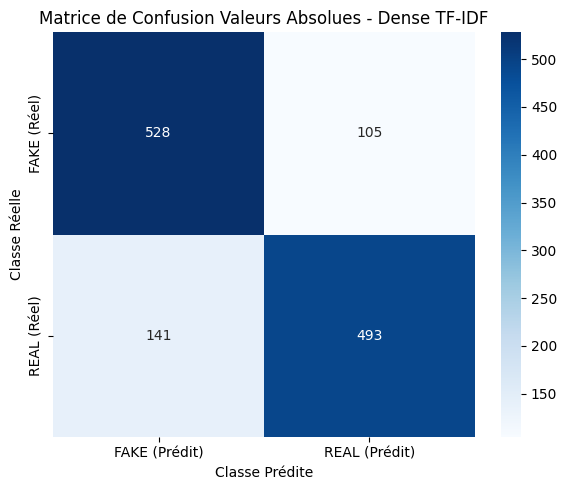

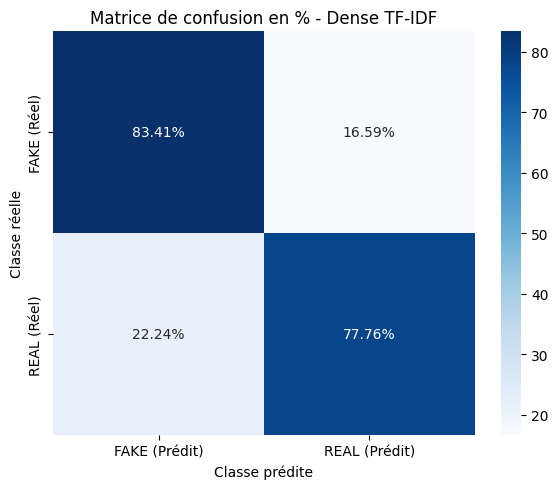


Rapport de classification :
              precision    recall  f1-score   support

        FAKE       0.79      0.83      0.81       633
        REAL       0.82      0.78      0.80       634

    accuracy                           0.81      1267
   macro avg       0.81      0.81      0.81      1267
weighted avg       0.81      0.81      0.81      1267



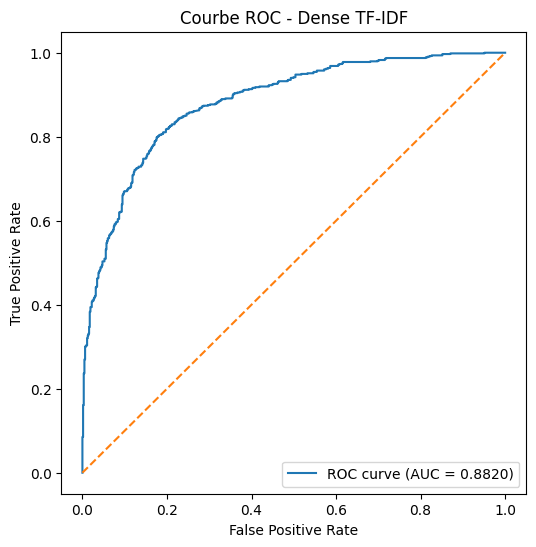

In [25]:
best_model_name = "Dense TF-IDF"
best_y_true = y_test_clean
best_y_pred = y_pred_dense
best_y_proba = y_proba_dense
best_titles = X_test_clean.reset_index(drop=True)

cm = confusion_matrix(best_y_true, best_y_pred)
cm_percent = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis] * 100

# print("Matrice de confusion :")
# print(cm)

# Création de la figure
plt.figure(figsize=(6, 5))
sns.heatmap(cm, 
            annot=True,          # Affiche les valeurs brutes dans les cases
            fmt="d",             # Format entier ("d" pour decimal)
            cmap="Blues",       # Couleur bleue dégradée
            xticklabels=["FAKE (Prédit)", "REAL (Prédit)"], 
            yticklabels=["FAKE (Réel)", "REAL (Réel)"])
plt.title(f"Matrice de Confusion Valeurs Absolues - {best_model_name}", fontsize=12)
plt.ylabel("Classe Réelle", fontsize=10)
plt.xlabel("Classe Prédite", fontsize=10)
plt.tight_layout()
plt.show()


labels = np.array([[f"{value:.2f}%" for value in row] for row in cm_percent])

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_percent,
    annot=labels,
    fmt="",
    cmap="Blues",
    xticklabels=["FAKE (Prédit)", "REAL (Prédit)"],
    yticklabels=["FAKE (Réel)", "REAL (Réel)"]
)

plt.title(f"Matrice de confusion en % - {best_model_name}", fontsize=12)
plt.ylabel("Classe réelle", fontsize=10)
plt.xlabel("Classe prédite", fontsize=10)
plt.tight_layout()
plt.show()


print("\nRapport de classification :")
print(classification_report(best_y_true, best_y_pred, target_names=["FAKE", "REAL"]))

fpr, tpr, thresholds = roc_curve(best_y_true, best_y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"Courbe ROC - {best_model_name}")
plt.legend(loc="lower right")
plt.show()

# 5.2 Analyse des erreurs


In [26]:
results_df = pd.DataFrame({
    "text_raw": X_test_clean.reset_index(drop=True),
    "label_true": best_y_true.to_numpy(dtype="int32"),
    "label_pred": best_y_pred,
    "score_real": best_y_proba
})

false_positives = results_df[(results_df["label_true"] == 0) & (results_df["label_pred"] == 1)].copy()
false_negatives = results_df[(results_df["label_true"] == 1) & (results_df["label_pred"] == 0)].copy()

# false_positives["confidence_fake"] = 1 - false_positives["score_real"]
# false_negatives["confidence_real"] = false_negatives["score_real"]

false_positives["confidence_real"] = false_positives["score_real"]
false_negatives["confidence_fake"] = 1 - false_negatives["score_real"]

# false_positives = false_positives.sort_values("confidence_fake", ascending=False).head(15)
# false_negatives = false_negatives.sort_values("confidence_real", ascending=False).head(15)

false_positives = false_positives.sort_values("confidence_real", ascending=False).head(15)
false_negatives = false_negatives.sort_values("confidence_fake", ascending=False).head(15)

* Les 15 faux positifs (titres REAL classifiés FAKE) ayant le score de confiance le plus élevé

In [27]:
print(false_positives[["text_raw", "confidence_real"]])


                                               text_raw  confidence_real
127   noun verb donald trump rubio seeks seize murph...         0.971764
1248  awesome video show real donald trump president...         0.958242
247   look paul ryan masochist paul nehlen gun house...         0.942776
340   washington 's embargo cuba not effective isola...         0.929827
991   comment circulate republican presidential cand...         0.918186
1227  plan parenthood abortion pill usage rival surgery         0.917463
578   comment wikileak shocker clinton camp consider...         0.916574
838   green party margaret flower challenge we senat...         0.911477
1184        saudis foil isis terror attack pack stadium         0.909133
1163                  erdogan check obama bombing syria         0.907832
781                       iran finland sign mous tehran         0.904295
840   donald trump beg hillary clinton early voter c...         0.886299
769   peaceful sincerely grace paris attack commemo

* Les 15 faux négatifs (titres FAKE classifiés REAL) ayant le score de confiance le plus élevé

In [28]:
print(false_negatives[["text_raw", "confidence_fake"]])

                                               text_raw  confidence_fake
464                 trump warning rig election credible         0.970406
858   haywire hack medium refuse believe trump 's ru...         0.949287
6     page hack wikileak email teach we hillary clinton         0.945340
116   america simple ideology one russia 's top us e...         0.945052
117                                    no not world war         0.937032
201   trump lose cheating ask supporter watch pollin...         0.935555
423                       trump new rig system election         0.935082
1085            hillary supporter excite also practical         0.932436
397   reveal interview trump predict massive recessi...         0.909092
166                                   life among berned         0.907896
322                                    come job finally         0.907855
931   clinton foundation continue accept foreign mon...         0.901214
818          open carry come texas lone star state 

## 5.3 Robustesse
Testez le comportement du meilleur modèle sur les 10 titres suivants, que vous n'avez pas vus pendant l'entraînement. Affichez pour chacun la classe prédite et le score de confiance :

1. "Scientists discover new treatment for common disease"
2. "SHOCKING: Government hiding truth about water supply"
3. "Local elections results announced in three counties"
4. "You won't believe what this celebrity did last night"
5. "Central bank raises interest rates by 0.25 points"
6. "This one weird trick cures all allergies naturally"
7. "Parliament votes on new environmental legislation"
8. "Doctors don't want you to know this secret remedy"
9. "Tech company reports quarterly earnings below forecast"
10. "EXCLUSIVE: Famous actor reveals hidden agenda of elites"
Commentez : les prédictions vous semblent-elles cohérentes ? Y a-t-il des titres pour lesquels le modèle se trompe manifestement ou hésite ?

In [29]:
robust_titles = [
    "Scientists discover new treatment for common disease",
    "SHOCKING: Government hiding truth about water supply",
    "Local elections results announced in three counties",
    "You won't believe what this celebrity did last night",
    "Central bank raises interest rates by 0.25 points",
    "This one weird trick cures all allergies naturally",
    "Parliament votes on new environmental legislation",
    "Doctors don't want you to know this secret remedy",
    "Tech company reports quarterly earnings below forecast",
    "EXCLUSIVE: Famous actor reveals hidden agenda of elites"
]

robust_titles_clean = [clean_title(title) for title in robust_titles]
robust_vectors = tfidf.transform(robust_titles_clean).toarray()

robust_probs = model_dense.predict(robust_vectors, verbose=0).ravel()
robust_preds = (robust_probs >= 0.5).astype(int)

robust_df = pd.DataFrame({
    "title": robust_titles,
    "label": ["REAL" if x == 1 else "FAKE" for x in robust_preds],
    "confidence_real": np.round(robust_probs, 4)
})

robust_df

,title,label,confidence_real
0,Scientists discover new treatment for common d...,FAKE,0.3383
1,SHOCKING: Government hiding truth about water ...,FAKE,0.0639
2,Local elections results announced in three cou...,FAKE,0.3944
3,You won't believe what this celebrity did last...,REAL,0.7586
4,Central bank raises interest rates by 0.25 points,FAKE,0.3035
5,This one weird trick cures all allergies natur...,FAKE,0.1550
6,Parliament votes on new environmental legislation,FAKE,0.2131
7,Doctors don't want you to know this secret remedy,FAKE,0.3202
8,Tech company reports quarterly earnings below ...,FAKE,0.1910
9,EXCLUSIVE: Famous actor reveals hidden agenda ...,FAKE,0.2176


**=> Les prédictions du modèle sont cohérentes pour les titres sensationna ou complotistes, qu’il classe** **majoritairement comme FAKE. Cependant, plusieurs titres au ton neutre et informatif** 
**sont également classés comme FAKE, ce qui suggère des erreurs de classification.**

# BONUS : tentative d'amélioration des modèles

**Modèle baseline — réseau dense sur TF-IDF**

Epoch 1/15
129/135 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5427 - loss: 1.0493
Epoch 1: val_accuracy improved from None to 0.74474, saving model to ../models/best_model_ameliore.keras

Epoch 1: finished saving model to ../models/best_model_ameliore.keras
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5973 - loss: 0.8816 - val_accuracy: 0.7447 - val_loss: 0.7561
Epoch 2/15
131/135 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6689 - loss: 0.7412
Epoch 2: val_accuracy did not improve from 0.74474
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6842 - loss: 0.7277 - val_accuracy: 0.7447 - val_loss: 0.7108
Epoch 3/15
 87/135 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6910 - loss: 0.7042
Epoch 3: val_accuracy improved from 0.74474 to 0.76447, saving model to ../models/best_model_ameliore.keras

Epoch 3: finished saving model to ../models/best_model_ameliore.keras
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7104 - loss: 0.6976 - val_accuracy: 0.7645 - va

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 32)             │        96,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 289,733 (1.11 MB)

 Trainable params: 96,577 (377.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 193,156 (754.52 KB)

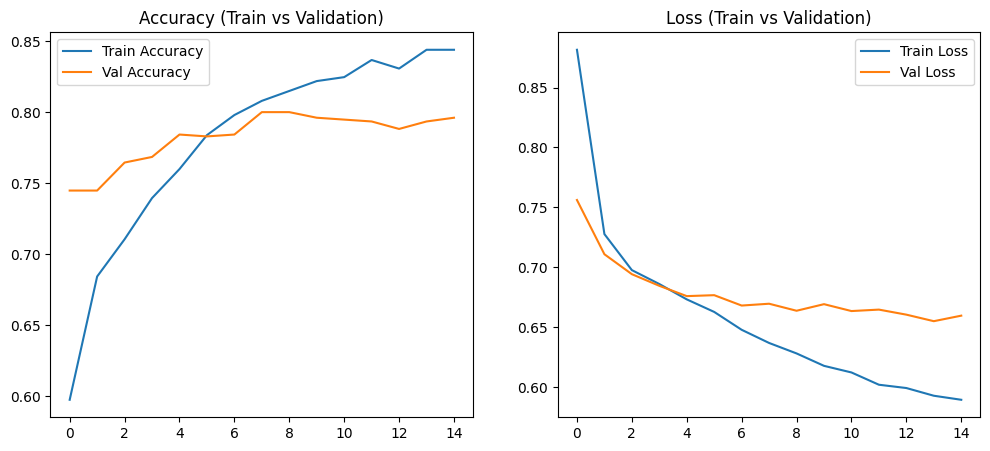

In [30]:
callbacks_baseline = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint('../models/best_model_ameliore.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]

model_baseline_ameliore = Sequential([
    Dense(32, activation='relu',kernel_regularizer='l2'),
    Dropout(0.5),
    Dense(16, activation='relu',kernel_regularizer='l2'),
    Dropout(0.4),
    Dense(1, activation='sigmoid') 
])


model_baseline_ameliore.compile(
    optimizer="adam",
    loss='binary_crossentropy',
    metrics=['accuracy']
)



history_baseline_ameliore = model_baseline_ameliore.fit(
    X_train_tfidf,
    y_train_clean,
    epochs=15,
    validation_split=0.15,
    callbacks=callbacks_baseline,
    verbose=1
)

model_baseline_ameliore.summary()

acc = history_baseline_ameliore.history['accuracy']
val_acc = history_baseline_ameliore.history['val_accuracy']
loss = history_baseline_ameliore.history['loss']
val_loss = history_baseline_ameliore.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

# Courbe d'Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Train Accuracy')
plt.plot(epochs_range, val_acc, label='Val Accuracy')
plt.title('Accuracy (Train vs Validation)')
plt.legend()

# Courbe de Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Train Loss')
plt.plot(epochs_range, val_loss, label='Val Loss')
plt.title('Loss (Train vs Validation)')
plt.legend()

In [31]:
# Analyse de l'overfitting
train_loss_final = history_baseline_ameliore.history['loss'][-1]
val_loss_final = history_baseline_ameliore.history['val_loss'][-1]
overfitting_gap = val_loss_final - train_loss_final

print(f"Train Loss Final: {train_loss_final:.4f}")
print(f"Val Loss Final: {val_loss_final:.4f}")
print(f"Overfitting Gap: {overfitting_gap:.4f}")

if overfitting_gap < 0.05:
    print("=> Peu d'overfitting détecté")
elif overfitting_gap < 0.15:
    print("=> Overfitting modéré")
else:
    print("=> Overfitting significatif")

Train Loss Final: 0.5893
Val Loss Final: 0.6595
Overfitting Gap: 0.0702
=> Overfitting modéré


In [32]:
robust_titles = [
    "Scientists discover new treatment for common disease",
    "SHOCKING: Government hiding truth about water supply",
    "Local elections results announced in three counties",
    "You won't believe what this celebrity did last night",
    "Central bank raises interest rates by 0.25 points",
    "This one weird trick cures all allergies naturally",
    "Parliament votes on new environmental legislation",
    "Doctors don't want you to know this secret remedy",
    "Tech company reports quarterly earnings below forecast",
    "EXCLUSIVE: Famous actor reveals hidden agenda of elites"
]

robust_titles_clean = [clean_title(title) for title in robust_titles]
robust_vectors = tfidf.transform(robust_titles_clean).toarray()

robust_probs = model_baseline_ameliore.predict(robust_vectors, verbose=0).ravel()
robust_preds = (robust_probs >= 0.5).astype(int)

robust_df = pd.DataFrame({
    "title": robust_titles,
    "label": ["REAL" if x == 1 else "FAKE" for x in robust_preds],
    "confidence_real": np.round(robust_probs, 4)
})

print(robust_df)

                                               title label  confidence_real
0  Scientists discover new treatment for common d...  FAKE           0.4315
1  SHOCKING: Government hiding truth about water ...  FAKE           0.1426
2  Local elections results announced in three cou...  FAKE           0.3330
3  You won't believe what this celebrity did last...  REAL           0.6070
4  Central bank raises interest rates by 0.25 points  FAKE           0.3810
5  This one weird trick cures all allergies natur...  FAKE           0.1396
6  Parliament votes on new environmental legislation  FAKE           0.3237
7  Doctors don't want you to know this secret remedy  FAKE           0.2779
8  Tech company reports quarterly earnings below ...  FAKE           0.2356
9  EXCLUSIVE: Famous actor reveals hidden agenda ...  FAKE           0.3348


Epoch 1/30
134/135 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5364 - loss: 0.9892
Epoch 1: val_loss improved from None to 0.68656, saving model to ../models/best_model_bilstm_ameliore.keras

Epoch 1: finished saving model to ../models/best_model_bilstm_ameliore.keras
135/135 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.5950 - loss: 0.8809 - val_accuracy: 0.7066 - val_loss: 0.6866
Epoch 2/30
133/135 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7735 - loss: 0.5875
Epoch 2: val_loss improved from 0.68656 to 0.48994, saving model to ../models/best_model_bilstm_ameliore.keras

Epoch 2: finished saving model to ../models/best_model_bilstm_ameliore.keras
135/135 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.8017 - loss: 0.5124 - val_accuracy: 0.8158 - val_loss: 0.4899
Epoch 3/30
133/135 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8624 - loss: 0.3946
Epoch 3: val_loss did not improve from 0.48994
135/135 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.8720 - loss: 0.3600 - val

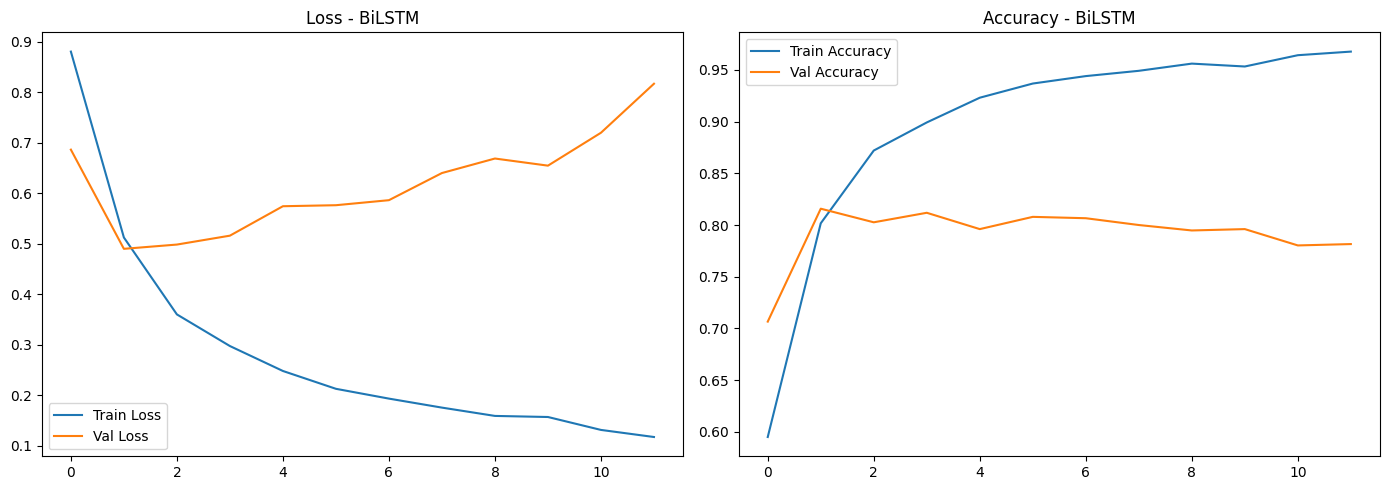

Temps d'entraînement BiLSTM : 34.95 s


In [33]:
text_vectorizer = tf.keras.layers.TextVectorization(
    max_tokens=3000,
    output_sequence_length=30,
    standardize="lower_and_strip_punctuation" # Nettoyage standard intégré
)

# On "apprend" le vocabulaire sur les données propres (et seulement sur le train !)
text_vectorizer.adapt(X_train_raw.to_numpy())

early_stop_bilstm = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1
)

checkpoint_bilstm = ModelCheckpoint(
    "../models/best_model_bilstm_ameliore.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

callbacks=[early_stop_bilstm, checkpoint_bilstm]

model_bilstm_ameliore = Sequential([
    keras.Input(shape=(1,), dtype=tf.string),
    text_vectorizer,
    Embedding(input_dim=3000, output_dim=16, mask_zero=True),
    Bidirectional(LSTM(32, dropout=0.4, recurrent_dropout=0.4)),
    Dense(32, activation="relu", kernel_regularizer='l2'),
    Dropout(0.5),
    Dense(1, activation="sigmoid")
])

model_bilstm_ameliore.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Conversion explicite en tenseurs TensorFlow (conforme au moteur Keras/Optree)
X_train_raw_tensor = tf.convert_to_tensor(X_train_raw.values, dtype=tf.string)
y_train_raw_tensor = tf.convert_to_tensor(y_train_raw.values, dtype=tf.int32)

start_bilstm = time.time()

# Lancement de l'entraînement avec les tenseurs
history_bilstm_ameliore = model_bilstm_ameliore.fit(
    X_train_raw_tensor,
    y_train_raw_tensor,
    validation_split=0.15,
    epochs=30,
    callbacks=callbacks,
    verbose=1
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[1].plot(history_bilstm_ameliore.history["accuracy"], label="Train Accuracy")
axes[1].plot(history_bilstm_ameliore.history["val_accuracy"], label="Val Accuracy")
axes[1].set_title("Accuracy - BiLSTM")
axes[1].legend()

axes[0].plot(history_bilstm_ameliore.history["loss"], label="Train Loss")
axes[0].plot(history_bilstm_ameliore.history["val_loss"], label="Val Loss")
axes[0].set_title("Loss - BiLSTM")
axes[0].legend()

plt.tight_layout()
plt.show()

bilstm_train_time = time.time() - start_bilstm
print(f"Temps d'entraînement BiLSTM : {bilstm_train_time:.2f} s")


In [35]:
# Analyse de l'overfitting
train_loss_final = history_bilstm_ameliore.history['loss'][-1]
val_loss_final = history_bilstm_ameliore.history['val_loss'][-1]
overfitting_gap = val_loss_final - train_loss_final

print(f"Train Loss Final: {train_loss_final:.4f}")
print(f"Val Loss Final: {val_loss_final:.4f}")
print(f"Overfitting Gap: {overfitting_gap:.4f}")

if overfitting_gap < 0.05:
    print("=> Peu d'overfitting détecté")
elif overfitting_gap < 0.15:
    print("=> Overfitting modéré")
else:
    print("=> Overfitting significatif")

Train Loss Final: 0.1169
Val Loss Final: 0.8172
Overfitting Gap: 0.7003
=> Overfitting significatif


**=>Diminution de l'overfitting grace à la modification de ces paramètre sur le modèle réseau dense TFIDF  :**

    - Diminution de la taille du vocabulaire
    - Augmentation du dropout
    - Diminution du nombre de neurones
    - Ajout de la régularisation L2  sur les couches dense